# señales desde github

## 13 repositorios que anticipan el software que viene

en este notebook exploro una pequeña selección personal de repositorios que me han llamado la atención. no intento construir un ranking ni decidir cuál es el mejor. mi objetivo es observar qué tienen en común y qué señales ofrecen sobre el futuro del software abierto, el autoalojamiento y las herramientas basadas en inteligencia artificial.

trabajo con metadatos públicos de github y añado una clasificación editorial manual. separo ambas capas para que los datos observados no se confundan con mi interpretación.

## preguntas

quiero responder cuatro preguntas sencillas:

1. ¿qué tipos de proyecto aparecen en la selección?
2. ¿qué relación observo entre popularidad, antigüedad y actividad reciente?
3. ¿cuántos proyectos se presentan como productos utilizables y no solo como código o recursos?
4. ¿qué señales encuentro sobre autoalojamiento, inteligencia artificial y alternativas abiertas al software comercial?

> nota: las estrellas y los forks cambian continuamente. los uso como contexto, no como una medida directa de calidad.

In [1]:
# importo las librerías que necesito para consultar, ordenar y visualizar los datos
from datetime import datetime, timezone
from pathlib import Path
import json
import os
import urllib.error
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ajusto la presentación para que las tablas y los gráficos sean fáciles de leer
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 90)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold"})

## selección y clasificación editorial

defino los repositorios y añado cinco etiquetas binarias. estas etiquetas son mi lectura editorial y no proceden de github:

- `producto`: puedo utilizarlo como una aplicación o herramienta concreta.
- `autoalojable`: puedo desplegar una parte relevante en infraestructura propia.
- `ia`: la inteligencia artificial forma parte central del producto o del flujo de trabajo.
- `educación`: su función principal es enseñar o reunir materiales formativos.
- `recopilación`: organiza enlaces o proyectos creados por terceros.

In [2]:
# describo mi selección y mantengo separadas las etiquetas que dependen de mi criterio
proyectos = [
    {"repositorio": "mouredev/hello-sql", "categoría": "educación", "producto": 0, "autoalojable": 0, "ia": 0, "educación": 1, "recopilación": 0},
    {"repositorio": "VintaBytes/Ciencia-de-datos", "categoría": "educación", "producto": 0, "autoalojable": 0, "ia": 0, "educación": 1, "recopilación": 0},
    {"repositorio": "dimartarmizi/map-to-poster", "categoría": "creatividad", "producto": 1, "autoalojable": 1, "ia": 0, "educación": 0, "recopilación": 0},
    {"repositorio": "mxpv/podsync", "categoría": "utilidad personal", "producto": 1, "autoalojable": 1, "ia": 0, "educación": 0, "recopilación": 0},
    {"repositorio": "bobeff/open-source-games", "categoría": "recopilación", "producto": 0, "autoalojable": 0, "ia": 0, "educación": 0, "recopilación": 1},
    {"repositorio": "liketrek/TREK", "categoría": "productividad", "producto": 1, "autoalojable": 1, "ia": 0, "educación": 0, "recopilación": 0},
    {"repositorio": "rmyndharis/OpenWA", "categoría": "infraestructura", "producto": 1, "autoalojable": 1, "ia": 0, "educación": 0, "recopilación": 0},
    {"repositorio": "multica-ai/multica", "categoría": "agentes", "producto": 1, "autoalojable": 1, "ia": 1, "educación": 0, "recopilación": 0},
    {"repositorio": "corebunch/instatic", "categoría": "creatividad", "producto": 1, "autoalojable": 1, "ia": 1, "educación": 0, "recopilación": 0},
    {"repositorio": "opencut-app/opencut", "categoría": "creatividad", "producto": 1, "autoalojable": 1, "ia": 0, "educación": 0, "recopilación": 0},
    {"repositorio": "anil-matcha/open-generative-ai", "categoría": "ia generativa", "producto": 1, "autoalojable": 1, "ia": 1, "educación": 0, "recopilación": 0},
    {"repositorio": "miqdadbadjuber/anti-slop", "categoría": "agentes", "producto": 0, "autoalojable": 0, "ia": 1, "educación": 0, "recopilación": 0},
    {"repositorio": "aldegad/sprite-gen", "categoría": "creatividad", "producto": 1, "autoalojable": 1, "ia": 1, "educación": 0, "recopilación": 0},
]

clasificacion = pd.DataFrame(proyectos)
clasificacion

,repositorio,categoría,producto,autoalojable,ia,educación,recopilación
0,mouredev/hello-sql,educación,0,0,0,1,0
1,VintaBytes/Ciencia-de-datos,educación,0,0,0,1,0
2,dimartarmizi/map-to-poster,creatividad,1,1,0,0,0
3,mxpv/podsync,utilidad personal,1,1,0,0,0
4,bobeff/open-source-games,recopilación,0,0,0,0,1
5,liketrek/TREK,productividad,1,1,0,0,0
6,rmyndharis/OpenWA,infraestructura,1,1,0,0,0
7,multica-ai/multica,agentes,1,1,1,0,0
8,corebunch/instatic,creatividad,1,1,1,0,0
9,opencut-app/opencut,creatividad,1,1,0,0,0


## consulta de datos públicos

consulto la api pública de github una vez por repositorio. si defino la variable de entorno `github_token`, añado el token a la petición para disponer de un límite de consultas mayor. para esta selección pequeña no debería ser necesario.

guardo una copia local de la respuesta en `datos_github.json`. así puedo volver a ejecutar el análisis aunque github no esté disponible o haya alcanzado temporalmente el límite de consultas.

In [3]:
# consulto github y guardo solo los campos que voy a utilizar
ruta_cache = Path("datos_github.json")
token = os.getenv("github_token")

def consultar_repositorio(nombre):
    # preparo una petición identificable y añado mi token solo si está disponible
    cabeceras = {"Accept": "application/vnd.github+json", "User-Agent": "nebula-repo-analysis"}
    if token:
        cabeceras["Authorization"] = f"Bearer {token}"
    peticion = urllib.request.Request(f"https://api.github.com/repos/{nombre}", headers=cabeceras)
    with urllib.request.urlopen(peticion, timeout=20) as respuesta:
        dato = json.load(respuesta)
    return {
        "repositorio": dato["full_name"],
        "descripción": dato.get("description"),
        "estrellas": dato["stargazers_count"],
        "forks": dato["forks_count"],
        "incidencias_abiertas": dato["open_issues_count"],
        "lenguaje": dato.get("language"),
        "licencia": (dato.get("license") or {}).get("spdx_id", "sin identificar"),
        "creado": dato["created_at"],
        "último_push": dato["pushed_at"],
        "archivado": dato["archived"],
        "url": dato["html_url"],
    }

try:
    # intento actualizar la copia para trabajar con cifras recientes
    datos_api = [consultar_repositorio(nombre) for nombre in clasificacion["repositorio"]]
    ruta_cache.write_text(json.dumps(datos_api, ensure_ascii=False, indent=2), encoding="utf-8")
    origen = "api de github actualizada"
except (urllib.error.URLError, urllib.error.HTTPError, TimeoutError) as error:
    # recupero mi última copia si la consulta falla y explico claramente su procedencia
    if not ruta_cache.exists():
        raise RuntimeError("no pude consultar github y todavía no existe una copia local") from error
    datos_api = json.loads(ruta_cache.read_text(encoding="utf-8"))
    origen = "copia local de la última consulta correcta"

print(f"origen de los datos: {origen}")

origen de los datos: api de github actualizada


In [4]:
# uno los metadatos con mi clasificación sin depender de las mayúsculas del nombre
clasificacion["clave"] = clasificacion["repositorio"].str.lower()
datos_api_df = pd.DataFrame(datos_api)
datos_api_df["clave"] = datos_api_df["repositorio"].str.lower()
datos = datos_api_df.merge(
    clasificacion.drop(columns="repositorio"), on="clave", how="left"
).drop(columns="clave")
ahora = pd.Timestamp.now(tz="utc")
datos["creado"] = pd.to_datetime(datos["creado"], utc=True)
datos["último_push"] = pd.to_datetime(datos["último_push"], utc=True)
datos["años_activo"] = ((ahora - datos["creado"]).dt.days / 365.25).round(1)
datos["días_desde_push"] = (ahora - datos["último_push"]).dt.days
datos["actividad_90_días"] = datos["días_desde_push"] <= 90

columnas = [
    "repositorio", "categoría", "estrellas", "forks", "lenguaje", "licencia",
    "años_activo", "días_desde_push", "producto", "autoalojable", "ia"
]
datos[columnas].sort_values("estrellas", ascending=False).reset_index(drop=True)

,repositorio,categoría,estrellas,forks,lenguaje,licencia,años_activo,días_desde_push,producto,autoalojable,ia
0,OpenCut-app/OpenCut,creatividad,90638,8958,TypeScript,MIT,1.3,0,1,1,0
1,multica-ai/multica,agentes,51314,6651,Go,NOASSERTION,0.7,0,1,1,1
2,Anil-matcha/Open-Generative-AI,ia generativa,29174,5313,JavaScript,MIT,3.4,0,1,1,1
3,bobeff/open-source-games,recopilación,15409,1284,Python,CC0-1.0,5.0,211,0,0,0
4,rmyndharis/OpenWA,infraestructura,14570,3401,TypeScript,MIT,0.6,0,1,1,0
5,liketrek/TREK,productividad,14346,1240,TypeScript,AGPL-3.0,0.5,0,1,1,0
6,mouredev/hello-sql,educación,10299,725,Python,Apache-2.0,3.0,542,0,0,0
7,CoreBunch/Instatic,creatividad,8785,822,TypeScript,MIT,0.4,11,1,1,1
8,miqdadbadjuber/anti-slop,agentes,3692,241,JavaScript,MIT,0.1,0,0,0,1
9,mxpv/podsync,utilidad personal,1963,314,Go,MIT,10.0,0,1,1,0


## popularidad y actividad

primero comparo las estrellas. utilizo una escala logarítmica porque unas pocas comunidades pueden ser mucho mayores que las demás. no interpreto esta cifra como calidad: un proyecto antiguo, educativo o dirigido a una comunidad amplia dispone de más oportunidades para acumular estrellas.

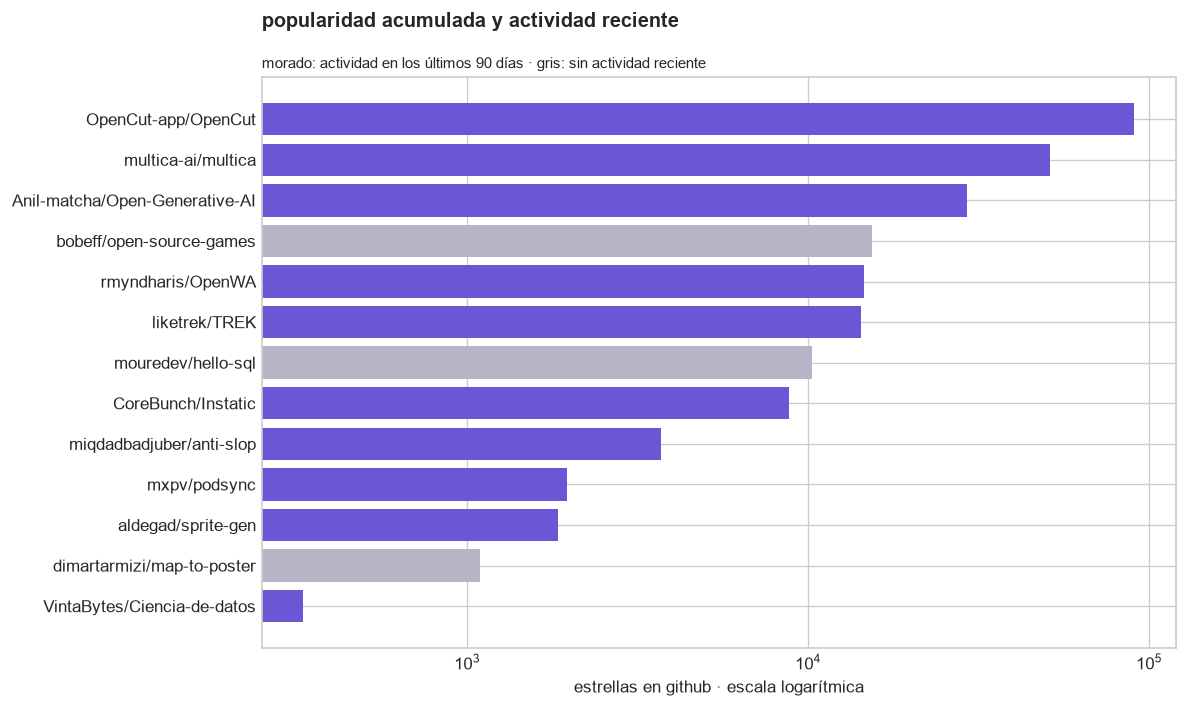

In [5]:
# ordeno los repositorios para mostrar las diferencias sin convertirlas en una puntuación de calidad
grafico = datos.sort_values("estrellas", ascending=True).copy()
colores = np.where(grafico["actividad_90_días"], "#6957d5", "#b8b3c7")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(grafico["repositorio"], grafico["estrellas"].clip(lower=1), color=colores)
ax.set_xscale("log")
ax.set_title("popularidad acumulada y actividad reciente", loc="left", pad=30)
ax.set_xlabel("estrellas en github · escala logarítmica")
ax.set_ylabel("")
ax.text(0, 1.01, "morado: actividad en los últimos 90 días · gris: sin actividad reciente", transform=ax.transAxes, fontsize=9, va="bottom")
plt.tight_layout()
plt.show()

## las señales de la selección

a continuación represento mi clasificación editorial como un mapa de atributos. este gráfico permite ver si la selección está dominada por recursos, productos completos, proyectos autoalojables o herramientas relacionadas con inteligencia artificial.

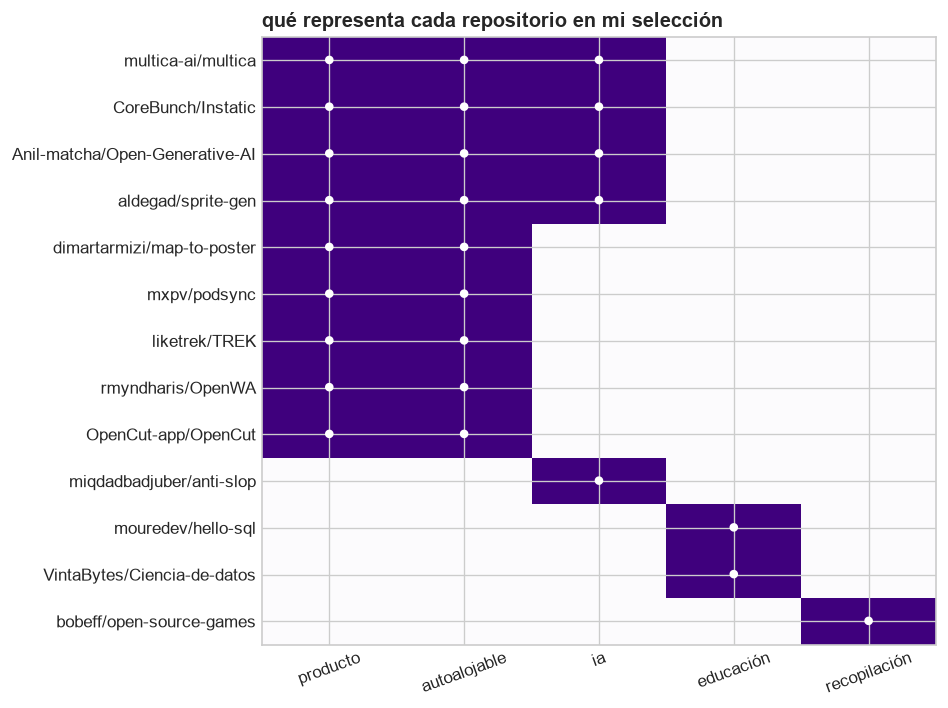

In [6]:
# convierto mis etiquetas en una matriz visual para reconocer patrones rápidamente
atributos = ["producto", "autoalojable", "ia", "educación", "recopilación"]
matriz = datos.set_index("repositorio")[atributos].sort_values(
    atributos, ascending=[False, False, False, False, False]
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(matriz.values, cmap="Purples", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(atributos)), atributos)
ax.set_yticks(range(len(matriz.index)), matriz.index)
ax.set_title("qué representa cada repositorio en mi selección", loc="left")

# escribo una marca dentro de cada celda para facilitar la lectura sin depender únicamente del color
for fila in range(matriz.shape[0]):
    for columna in range(matriz.shape[1]):
        if matriz.iloc[fila, columna] == 1:
            ax.text(columna, fila, "●", ha="center", va="center", color="white", fontsize=12)

ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## resumen reproducible

cierro el análisis calculando algunos resultados directamente a partir de la tabla. utilizo estos valores como apoyo para el artículo, pero reviso cada proyecto individualmente antes de formular una conclusión sobre su licencia, madurez o dependencia de servicios externos.

In [7]:
# resumo las señales más útiles para redactar el artículo
resumen = pd.Series({
    "repositorios analizados": len(datos),
    "productos utilizables": int(datos["producto"].sum()),
    "proyectos autoalojables": int(datos["autoalojable"].sum()),
    "proyectos relacionados con ia": int(datos["ia"].sum()),
    "actividad en los últimos 90 días": int(datos["actividad_90_días"].sum()),
    "licencias identificadas": int((~datos["licencia"].isin(["sin identificar", "NOASSERTION", "OTHER"])).sum()),
})

display(resumen.to_frame("resultado"))
print(f"el repositorio con más estrellas de la selección es {datos.loc[datos['estrellas'].idxmax(), 'repositorio']}.")
print(f"la categoría más frecuente en mi clasificación es {datos['categoría'].mode().iat[0]}.")

,resultado
repositorios analizados,13
productos utilizables,9
proyectos autoalojables,9
proyectos relacionados con ia,5
actividad en los últimos 90 días,10
licencias identificadas,11


el repositorio con más estrellas de la selección es OpenCut-app/OpenCut.
la categoría más frecuente en mi clasificación es creatividad.


## lectura editorial y predicciones

los datos no demuestran por sí solos cómo será el futuro del software. sí me ayudan a ordenar tres señales que después puedo contrastar con la documentación de cada proyecto:

1. **el código abierto se presenta cada vez más como producto.** una parte importante de la selección ofrece una interfaz y un caso de uso comprensible fuera del desarrollo de software.
2. **el autoalojamiento se acerca a tareas cotidianas y creativas.** ya no se limita a servidores o bases de datos: aparece en viajes, edición de vídeo, publicación web y consumo de contenidos.
3. **la inteligencia artificial se especializa.** los proyectos más reveladores no ofrecen únicamente un chat; coordinan agentes, imponen criterios de calidad o convierten una generación en un recurso preparado para producción.

a partir de estas señales planteo tres predicciones para el artículo:

- crecerán las alternativas abiertas a productos creativos de suscripción, aunque muchas competirán principalmente mediante servicios alojados y soporte.
- los agentes se integrarán en espacios de trabajo compartidos y necesitarán reglas, supervisión y mecanismos claros de entrega.
- la ventaja dejará de estar en generar más contenido y pasará a estar en convertirlo en resultados específicos, coherentes y utilizables.

## límites

mi selección es intencional y pequeña, por lo que no representa el conjunto de github. las estrellas favorecen a proyectos antiguos, populares o dirigidos a comunidades grandes. una actualización reciente tampoco garantiza continuidad. además, `autoalojable`, `código visible` y `código abierto` no significan lo mismo: antes de publicar el artículo revisaré la licencia y las dependencias reales de cada proyecto.